## Gurobi Optimization Suite
Simple quadratic programming problem verifying the availability and functionality of Gurobi's python interface.

In [1]:
def test_gurobipy_qp():
    # This example formulates and solves the following simple QP model:
    #  minimize
    #      x^2 + x*y + y^2 + y*z + z^2 + 2 x
    #  subject to
    #      x + 2 y + 3 z >= 4
    #      x +   y       >= 1
    #      x, y, z non-negative
    #
    # It solves it once as a continuous model, and once as an integer model.

    import gurobipy as gp
    from gurobipy import GRB

    # Create a new model
    m = gp.Model("qp")

    # Create variables
    x = m.addVar(ub=1.0, name="x")
    y = m.addVar(ub=1.0, name="y")
    z = m.addVar(ub=1.0, name="z")

    # Set objective: x^2 + x*y + y^2 + y*z + z^2 + 2 x
    obj = x**2 + x*y + y**2 + y*z + z**2 + 2*x
    m.setObjective(obj)

    # Add constraint: x + 2 y + 3 z >= 4
    m.addConstr(x + 2 * y + 3 * z >= 4, "c0")

    # Add constraint: x + y >= 1
    m.addConstr(x + y >= 1, "c1")

    m.optimize()

    for v in m.getVars():
        print('%s %g' % (v.VarName, v.X))

    print('Obj: %g' % obj.getValue())

    x.VType = GRB.INTEGER
    y.VType = GRB.INTEGER
    z.VType = GRB.INTEGER

    m.optimize()

    for v in m.getVars():
        print('%s %g' % (v.VarName, v.X))

    print('Obj: %g' % obj.getValue())
    pass

### Results

In [2]:
test_gurobipy_qp()

Set parameter TokenServer to value "gurobilicense.davidson.edu"
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel(R) Xeon(R) Gold 5218 CPU @ 2.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 32 physical cores, 64 logical processors, using up to 32 threads

Optimize a model with 2 rows, 3 columns and 5 nonzeros
Model fingerprint: 0xc501370b
Model has 5 quadratic objective terms
Coefficient statistics:
  Matrix range     [1e+00, 3e+00]
  Objective range  [2e+00, 2e+00]
  QObjective range [2e+00, 2e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+00]
Presolve time: 0.00s
Presolved: 2 rows, 3 columns, 5 nonzeros
Presolved model has 5 quadratic objective terms
Ordering time: 0.00s

Barrier statistics:
 Free vars  : 2
 AA' NZ     : 6.000e+00
 Factor NZ  : 1.000e+01
 Factor Ops : 3.000e+01 (less than 1 second per iteration)
 Threads    : 1

                  Objective                Residual
Iter       Primal          Dual         Pri

## SCIP Optimization Suite
Linear programming problem verifying the availability and functioning of the python interface for the SCIP Optimization Suite.

In [3]:
def test_pyscipopt_lp():
    """
     On a beach there are octopuses, turtles and cranes.
     The total number of legs of all animals is 80, while the number of heads is 32.
     What are the minimum numbers of turtles and octopuses, respectively?
  
     Copyright (c) by Joao Pedro PEDROSO and Mikio KUBO, 2012
    """
    from pyscipopt import Model
  
    model = Model("puzzle")
    x = model.addVar(vtype="I", name="octopusses")
    y = model.addVar(vtype="I", name="turtles")
    z = model.addVar(vtype="I", name="cranes")
  
    # Set up constraint for number of heads
    model.addCons(x + y + z == 32, name="Heads")
  
    # Set up constraint for number of legs
    model.addCons(8*x + 4*y + 2*z == 80, name="Legs")
  
    # Set objective function
    model.setObjective(x + y, "minimize")
  
    model.hideOutput()
    model.optimize()
  
    #solution = model.getBestSol()
  
    print("Optimal value:", model.getObjVal())
    print((x.name, y.name, z.name), 
          " = ", 
          (model.getVal(x), model.getVal(y), model.getVal(z)))


### Results

In [4]:
test_pyscipopt_lp()

Optimal value: 4.0
('octopusses', 'turtles', 'cranes')  =  (2.0, 2.0, 28.0)


## OR-Tools
Simple Linear programming problem verifying the availability of a functioning `ortools` install

In [5]:
def test_ortools_lp():    
    """Linear programming sample."""
    from ortools.linear_solver import pywraplp

    # Instantiate a Glop solver, naming it LinearExample.
    solver = pywraplp.Solver.CreateSolver("GLOP")
    if not solver:
        return

    # Create the two variables and let them take on any non-negative value.
    x = solver.NumVar(0, solver.infinity(), "x")
    y = solver.NumVar(0, solver.infinity(), "y")

    print("Number of variables =", solver.NumVariables())

    # Constraint 0: x + 2y <= 14.
    solver.Add(x + 2 * y <= 14.0)

    # Constraint 1: 3x - y >= 0.
    solver.Add(3 * x - y >= 0.0)

    # Constraint 2: x - y <= 2.
    solver.Add(x - y <= 2.0)

    print("Number of constraints =", solver.NumConstraints())

    # Objective function: 3x + 4y.
    solver.Maximize(3 * x + 4 * y)

    # Solve the system.
    print(f"Solving with {solver}")
    status = solver.Solve()

    if status == pywraplp.Solver.OPTIMAL:
        print("Solution:")
        print(f"Objective value = {solver.Objective().Value():0.1f}")
        print(f"x = {x.solution_value():0.1f}")
        print(f"y = {y.solution_value():0.1f}")
    else:
        print("The problem does not have an optimal solution.")

    print("\nAdvanced usage:")
    print(f"Problem solved in {solver.wall_time():d} milliseconds")
    print(f"Problem solved in {solver.iterations():d} iterations")


### Results

In [6]:
test_ortools_lp()

Number of variables = 2
Number of constraints = 3
Solving with <ortools.linear_solver.pywraplp.Solver; proxy of <Swig Object of type 'operations_research::MPSolver *' at 0x1542bfe99b00> >
Solution:
Objective value = 34.0
x = 6.0
y = 4.0

Advanced usage:
Problem solved in 1 milliseconds
Problem solved in 2 iterations


## Scientific Python Stack
The following test uses FEM to solve a 1D BVP, verifying the availability and basic functionality of `numpy`, `scipy`, `matplotlib`, and `panda`

In [7]:
def test_scipy_stack():
    import time
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    import platform
    import scipy.linalg as la

    #*****************************************************************************
    ## fem1d_test() solves a 1D boundary value problem using finite elements.
    #
    #  Discussion:
    #
    #    The PDE is defined for 0 < x < 1:
    #      -u'' = f
    #    with right hand side
    #      f(x) = -(exact(x)'') 
    #    and boundary conditions
    #      u(0) = exact(0),
    #      u(1) = exact(1).
    #
    #    The exact solution is:
    #      exact(x) = x * ( 1 - x ) * exp ( x )
    #    The boundary conditions are
    #      u(0) = 0.0 = exact(0.0),
    #      u(1) = 0.0 = exact(1.0).
    #    The right hand side is:
    #      f(x) = x * ( x + 3 ) * exp ( x ) = - ( exact''(x) )
    #
    #  Licensing:
    #    This code is distributed under the GNU LGPL license. 
    #
    #  Modified:
    #    13 September 2014
    #
    #  Author:
    #    John Burkardt
    #

    def exact_fn(x):
        value = x * ( 1 - x ) * np.exp ( x )
        return value

    def rhs_fn(x):
        value = x * ( x + 3 ) * np.exp ( x )
        return value

    def timestamp():
        t = time.time()
        print ( time.ctime ( t ) )
        return None

    #
    #  Define the mesh, N+1 points between A and B.
    #  These will be X[0] through X[N].
    #
    a = 0.0
    b = 1.0
    n = 20
    x = np.linspace ( a, b, n + 1 )

    
    #
    #  Set a 3 point quadrature rule on the reference interval [0,1].
    #
    ng = 3

    xg = np.array ( 
        (0.112701665379258311482073460022, 0.5, 0.887298334620741688517926539978)
    )

    wg = np.array ( 
        (5.0 / 18.0, 8.0 / 18.0, 5.0 / 18.0) 
    )
    
    #
    #  Compute the system matrix A and right hand side RHS.
    #
    A = np.zeros ( ( n + 1, n + 1 ) )
    rhs = np.zeros ( n + 1 )
    
    #
    #  Look at element E: (0, 1, 2, ..., N-1).
    #
    for e in range ( 0, n ):

        xl = x[e]
        xr = x[e+1]

        #
        #  Consider quadrature point Q: (0, 1, 2 ) in element E.
        #
        for q in range ( 0, ng ):
            #
            #  Map XG and WG from [0,1] to
            #      XQ and QQ in [XL,XR].
            #
            xq = xl + xg[q] * ( xr - xl )
            wq = wg[q] * ( xr - xl )

        #
        #  Consider the I-th test function PHI(I,X) and its derivative PHI'(I,X).
        #
        for i_local in range ( 0, 2 ):
            i = i_local + e

            if ( i_local == 0 ):
                phii = ( xq - xr ) / ( xl - xr )
                phiip = 1.0 / ( xl - xr )
            else:
                phii = ( xq - xl ) / ( xr - xl )
                phiip = 1.0 / ( xr - xl )

            rhs[i] = rhs[i] + wq * phii * rhs_fn ( xq )

            #
            #  Consider the J-th basis function PHI(J,X) and its derivative PHI'(J,X).
            #  (It turns out we don't need PHI for this particular problem, only PHI')
            #
            for j_local in range ( 0, 2 ):
                j = j_local + e

                if ( j_local == 0 ):
                    phijp = 1.0 / ( xl - xr )
                else:
                    phijp = 1.0 / ( xr - xl )

                A[i][j] = A[i][j] + wq * phiip * phijp

    #
    #  Modify the linear system to enforce the left boundary condition.
    #
    A[0,0] = 1.0
    A[0,1:n+1] = 0.0
    rhs[0] = exact_fn ( x[0] )
    
    #
    #  Modify the linear system to enforce the right boundary condition.
    #
    A[n,n] = 1.0
    A[n,0:n] = 0.0
    rhs[n] = exact_fn ( x[n] )
    
    #
    #  Solve the linear system.
    #
    u = la.solve ( A, rhs )
    
    #
    #  Evaluate the exact solution at the nodes.
    #
    uex = np.zeros ( n + 1 )
    for i in range ( 0, n + 1 ):
        uex[i] = exact_fn ( x[i] )
    
    #
    #  Plot the computed solution and the exact solution.
    #  Evaluate the exact solution at enough points that the curve will look smooth.
    #
    npp = 51
    xp = np.linspace ( a, b, npp )
    up = np.zeros ( npp )
    for i in range ( 0, npp ):
        up[i] = exact_fn ( xp[i] )

    plt.plot ( x, u, 'bo-', xp, up, 'r.' )
    plt.show ( block = False )
    plt.close ( )
    
    #
    #  Compare the solution and the error at the nodes.
    #
    err_table = pd.DataFrame(data={
        'Node': x,
        'Ucomp': u,
        'Uexact': uex,
        'Error': uex - u 
    })
    display(err_table.style.format(precision=5))
    pass

### Results

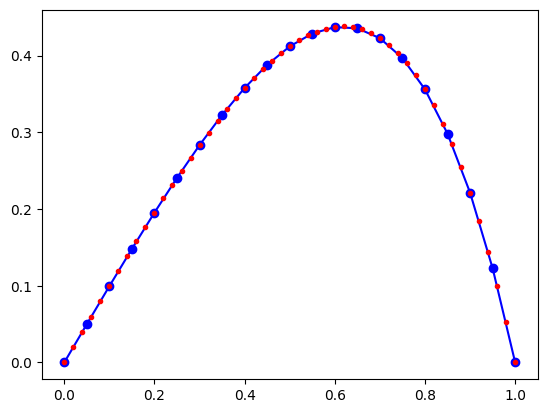

,Node,Ucomp,Uexact,Error
0,0.00000,0.00000,0.00000,-0.00000
1,0.05000,0.04990,0.04994,0.00003
2,0.10000,0.09941,0.09947,0.00006
3,0.15000,0.14805,0.14813,0.00009
4,0.20000,0.19531,0.19542,0.00011
5,0.25000,0.24062,0.24075,0.00013
6,0.30000,0.28332,0.28347,0.00016
7,0.35000,0.32267,0.32284,0.00017
8,0.40000,0.35785,0.35804,0.00019
9,0.45000,0.38796,0.38816,0.00020


In [8]:
test_scipy_stack()

## `scikit-learn` & `joblib`

The following tests the availability and basic functionality of `scikit-learn` and `joblib`, verifying their proper interaction.

In [9]:
def test_scikit_learn(with_plot=True):
    # Author: Alexandre Gramfort <alexandre.gramfort@inria.fr>
    #         Albert Thomas <albert.thomas@telecom-paristech.fr>
    # License: BSD 3 clause
    import time
    import matplotlib
    import matplotlib.pyplot as plt
    import numpy as np

    from sklearn.covariance import EllipticEnvelope
    from sklearn.datasets import make_blobs, make_moons
    from sklearn.ensemble import IsolationForest
    from sklearn.kernel_approximation import Nystroem
    from sklearn.linear_model import SGDOneClassSVM
    from sklearn.neighbors import LocalOutlierFactor
    from sklearn.pipeline import make_pipeline
    from sklearn.svm import OneClassSVM

    matplotlib.rcParams["contour.negative_linestyle"] = "solid"

    # Example settings
    n_samples = 1000
    outliers_fraction = 0.15
    n_outliers = int(outliers_fraction * n_samples)
    n_inliers = n_samples - n_outliers

    # define outlier/anomaly detection methods to be compared.
    # the SGDOneClassSVM must be used in a pipeline with a kernel approximation
    # to give similar results to the OneClassSVM
    anomaly_algorithms = [
        (
            "Robust covariance",
            EllipticEnvelope(contamination=outliers_fraction, random_state=42),
        ),
        ("One-Class SVM", OneClassSVM(nu=outliers_fraction, kernel="rbf", gamma=0.1)),
        (
            "One-Class SVM (SGD)",
            make_pipeline(
                Nystroem(gamma=0.1, random_state=42, n_components=150),
                SGDOneClassSVM(
                    nu=outliers_fraction,
                    shuffle=True,
                    fit_intercept=True,
                    random_state=42,
                    tol=1e-6,
                ),
            ),
        ),
        (
            "Isolation Forest",
            IsolationForest(contamination=outliers_fraction, random_state=42),
        ),
        (
            "Local Outlier Factor",
            LocalOutlierFactor(n_neighbors=35, contamination=outliers_fraction),
        ),
    ]

    # Define datasets
    blobs_params = dict(random_state=0, n_samples=n_inliers, n_features=2)
    datasets = [
        make_blobs(centers=[[0, 0], [0, 0]], cluster_std=0.5, **blobs_params)[0],
        make_blobs(centers=[[2, 2], [-2, -2]], cluster_std=[0.5, 0.5], **blobs_params)[0],
        make_blobs(centers=[[2, 2], [-2, -2]], cluster_std=[1.5, 0.3], **blobs_params)[0],
        4.0
        * (
            make_moons(n_samples=n_samples, noise=0.05, random_state=0)[0]
            - np.array([0.5, 0.25])
        ),
        14.0 * (np.random.RandomState(42).rand(n_samples, 2) - 0.5),
    ]


    # Compare given classifiers under given settings
    xx, yy = np.meshgrid(np.linspace(-7, 7, 150), np.linspace(-7, 7, 150))
    if with_plot:
        plt.figure(figsize=(len(anomaly_algorithms) * 1 + 2, 6.25))
        plt.subplots_adjust(
            left=0.02, right=0.98, bottom=0.001, top=0.96, wspace=0.05, hspace=0.01
        )

    plot_num = 1
    rng = np.random.RandomState(42)

    for i_dataset, X in enumerate(datasets):
        # Add outliers
        X = np.concatenate([X, rng.uniform(low=-6, high=6, size=(n_outliers, 2))], axis=0)

        for name, algorithm in anomaly_algorithms:
            t0 = time.time()
            algorithm.fit(X)
            t1 = time.time()

            if with_plot:
                plt.subplot(len(datasets), len(anomaly_algorithms), plot_num)
                if i_dataset == 0:
                    plt.title(name, size=10)

            # fit the data and tag outliers
            if name == "Local Outlier Factor":
                y_pred = algorithm.fit_predict(X)
            else:
                y_pred = algorithm.fit(X).predict(X)

            if with_plot:
                # plot the levels lines and the points
                if name != "Local Outlier Factor":  # LOF does not implement predict
                    Z = algorithm.predict(np.c_[xx.ravel(), yy.ravel()])
                    Z = Z.reshape(xx.shape)
                    plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors="black")

                colors = np.array(["#377eb8", "#ff7f00"])
                plt.scatter(X[:, 0], X[:, 1], s=10, color=colors[(y_pred + 1) // 2])

                plt.xlim(-7, 7)
                plt.ylim(-7, 7)
                plt.xticks(())
                plt.yticks(())
                plt.text(
                    0.99,
                    0.01,
                    ("%.2fs" % (t1 - t0)).lstrip("0"),
                    transform=plt.gca().transAxes,
                    size=15,
                    horizontalalignment="right",
                )
                plot_num += 1
                
    if with_plot:
        plt.show()
    pass

def test_joblib():
    """
     Name: test_joblib
     Synop: runs test_scikit_learn with different parallel backends
    """
    import time
    import pandas as pd
    from joblib import parallel_backend
    
    times = pd.DataFrame(columns=['time'], index=['threading', 'multiprocessing', 'loky'])
    for backend in ['threading', 'multiprocessing', 'loky']:
        times.loc[backend,'time'] = time.time()
        with parallel_backend(backend=backend, n_jobs=10):
            test_scikit_learn(with_plot=False)
        times.loc[backend,'time'] = time.time() - times.loc[backend,'time']
    display(times)



### Results

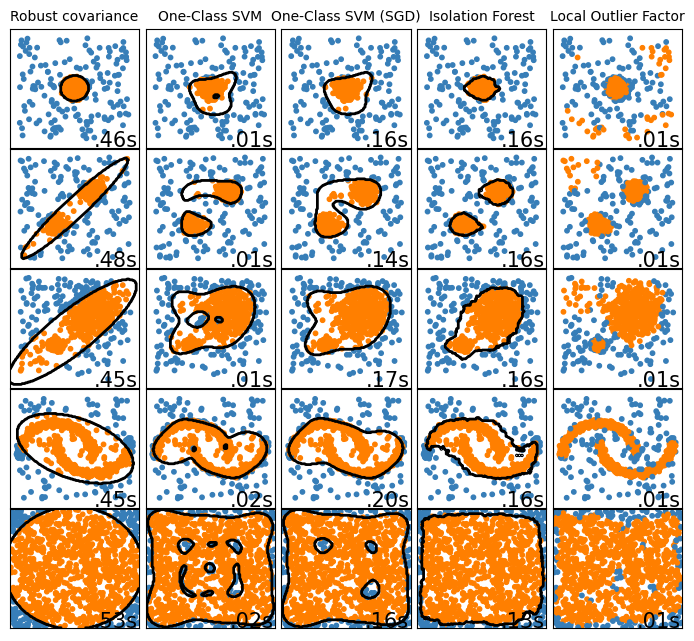

In [10]:
test_scikit_learn()

In [11]:
test_joblib()

,time
threading,9.459865
multiprocessing,12.309216
loky,10.120898
